# nonstar — MMD vs L2 guidance


In [65]:
import os
# ============================================================
# CONFIG
# Structure mirrors Exp_2D_cond_1D.ipynb:
#   simulations/src/        <- all .py modules
#   simulations/notebooks/  <- this notebook
#   simulations/params/     <- canonical GMM parameters (shared, load first)
#   simulations/checkpoints/
#   simulations/results/
# ============================================================
EXPERIMENT_NAME   = "nonstar"
GLOBAL_SEED       = 42
FORCE_RETRAIN     = True

# QUICK_RUN trades fidelity for wall-clock time (useful to smoke-test on CPU / no GPU).
# Set False for a full-fidelity run (needs a GPU for N_ATTEMP_OPTIM=25 in reasonable time).
QUICK_RUN         = False

BASE_DIR = os.path.normpath(os.path.join(os.getcwd(), ".."))
PARAMS_DIR        = f"{BASE_DIR}/params"
CHECKPOINT_DIR    = f"{BASE_DIR}/checkpoints/{EXPERIMENT_NAME}"
RESULTS_DIR       = f"{BASE_DIR}/results/{EXPERIMENT_NAME}"

# Architecture -- Diffusion (unconditional prior only; no conditional Diffusion/MLGD trained)
NBLOCKS           = 3
NUNITS            = 128

# Architecture -- Consistency Model (MLGD-F, the only conditional model trained)
NBLOCKS_CM        = 3
NUNITS_CM         = 128

# Training
NEPOCHS           = 2_000  if QUICK_RUN else 20_000
BATCH_SIZE        = 1_024
NEPOCHS_CM        = NEPOCHS
BATCH_SIZE_CM     = 1_024

# Diffusion
DIFFUSION_STEPS   = 100

# GMM dimensions
CONDITION_ON      = 1   # dim(x)=1, dim(y)=1

# --- nonstar scenario (verbatim from experiments/nonstar/nonstar.py) ---
X_BI, X_UNI = -2.0, 2.0        # the two candidate design points
SIGMA_X, SIGMA_Y = 0.7, 0.2    # joint GMM component std devs (isotropic per component)
Y_STAR      = 4.0              # requested target -- a point mass (sigma_t -> 0)
ZERO_SIGMA_EPS = 1e-6          # numerical floor so the target still has an invertible covariance

# # --- MMD vs L2 guidance loss ablation ---
ARMS = [
    ("MMD_n250", "MMD", 250),
    ("L2_n250",  "L2",  250),
    ("L2_n1",   "L2",   1),
]    # passed straight through to Optimization.optimize_LGD(loss=...)

# Optimization
N_ATTEMP_OPTIM     = 3   if QUICK_RUN else 25
NUM_X_T_LGD_CM     = 1

In [34]:
# Install dependencies if needed
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "flow_matching", "POT", "-q"])


0

In [35]:
import os, sys, time, json
import importlib
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
from tqdm import trange

import Diffusion
import LossFunctions
import ConsistencyModels
import dist_utils
import Optimization
import experiment_utils
from ConsistencyModels import ConsistencyModeliCT
from LossFunctions import MMDLoss, RBF

for mod in [Diffusion, LossFunctions, ConsistencyModels,
            dist_utils, Optimization, experiment_utils]:
    importlib.reload(mod)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Imports done.")


Imports done.


In [36]:
env_info = experiment_utils.get_environment_info()
experiment_utils.print_environment_info(env_info)


ENVIRONMENT INFO
  timestamp: 2026-09-20T07:01:27.666834
  torch_version: 2.11.0+cpu
  cuda_available: False
  cuda_version: None
  device_name: cpu
  packages: {'torch': '2.11.0+cpu', 'numpy': '2.1.3', 'flow_matching': '1.0.10', 'POT': '0.9.7.post1', 'matplotlib': '3.10.0', 'pandas': '2.2.3', 'tqdm': '4.67.3'}
  packages:


In [37]:
experiment_utils.set_global_seed(GLOBAL_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


[Seed] All random seeds set to 42
Using device: cpu


## Joint GMM (the `nonstar` scenario)

Three components over `(x, y)`: `(-2, 2)`, `(-2, 4)`, `(+2, 3)`, weights `(1/4, 1/4, 1/2)`,
diagonal covariance `diag(sigma_x^2, sigma_y^2)` per component. `x = -2` gives a bimodal
`P(Y|X)` on `{2, 4}`; `x = +2` gives a unimodal `P(Y|X) = N(3, sigma_y^2)`. Neither matches
`N(y*=4, sigma_t^2)` exactly -- that's the "no star" (no point that hits the target) setup.

There is no `x_star` here (unlike `Exp_2D_cond_1D.ipynb`) since, by construction, no single
design point realises the requested target.


In [38]:
GMM_PATH = os.path.join(PARAMS_DIR, f"{EXPERIMENT_NAME}_gmm_params.pt")

if os.path.exists(GMM_PATH) and not FORCE_RETRAIN:
    _saved = torch.load(GMM_PATH)
    mu_list, Sigma_list, alpha = _saved["mu_list"], _saved["Sigma_list"], _saved["alpha"]
    print(f"[GMM] Loaded from {GMM_PATH}")
else:
    mu_list = [
        torch.tensor([X_BI,  2.0]),
        torch.tensor([X_BI,  4.0]),
        torch.tensor([X_UNI, 3.0]),
    ]
    Sigma_list = [torch.diag(torch.tensor([SIGMA_X ** 2, SIGMA_Y ** 2]))] * len(mu_list)
    alpha = torch.tensor([0.25, 0.25, 0.50])

    os.makedirs(PARAMS_DIR, exist_ok=True)
    torch.save({"mu_list": mu_list, "Sigma_list": Sigma_list, "alpha": alpha}, GMM_PATH)
    print(f"[GMM] Parameters generated and saved to {GMM_PATH}")

mu_list    = [mu.float() for mu in mu_list]
Sigma_list = [cov.float() for cov in Sigma_list]
alpha      = alpha.float()
print(f"x_bi={X_BI}, x_uni={X_UNI}, {len(mu_list)} joint components")


[GMM] Parameters generated and saved to /content/conditional-matching-paper/simulations/params/nonstar_gmm_params.pt
x_bi=-2.0, x_uni=2.0, 3 joint components


## Data

[Seed] All random seeds set to 42


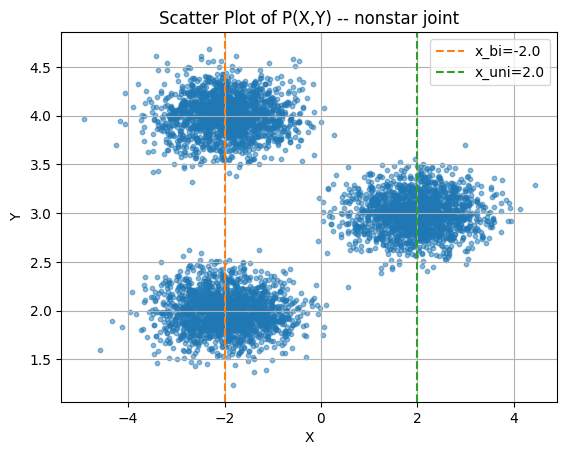

In [39]:
experiment_utils.set_global_seed(GLOBAL_SEED)
X = dist_utils.generate_mog_samples(5_000, mu_list, Sigma_list, alpha).float().to(device)
xh_cpu = X.detach().cpu().numpy()
plt.scatter(xh_cpu[:, 0], xh_cpu[:, 1], alpha=0.5, s=10)
plt.axvline(X_BI, color="C1", ls="--", label=f"x_bi={X_BI}")
plt.axvline(X_UNI, color="C2", ls="--", label=f"x_uni={X_UNI}")
plt.title("Scatter Plot of P(X,Y) -- nonstar joint")
plt.xlabel("X"); plt.ylabel("Y"); plt.legend(); plt.grid(True); plt.show()


## Train Models

### Consistency Model -- P(Y|X=x)  (MLGD-F)

In [40]:
experiment_utils.set_global_seed(GLOBAL_SEED)

B, C      = X.shape
nfeatures = C - CONDITION_ON
data_generator_cm = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha
)

Cos_ConsistencyModeliCT = ConsistencyModeliCT(
    nfeatures=nfeatures, condition_on=CONDITION_ON,
    nunits=NUNITS_CM, depth=NBLOCKS_CM
)

_loaded_cm = experiment_utils.load_checkpoint_with_hf_fallback(
    Cos_ConsistencyModeliCT, "CM", CHECKPOINT_DIR,
    EXPERIMENT_NAME, GLOBAL_SEED, device
) if not FORCE_RETRAIN else False

if not _loaded_cm:
    experiment_utils.set_global_seed(GLOBAL_SEED)
    Cos_ConsistencyModeliCT.train_model(
        X=None, nepochs=NEPOCHS_CM, batch_size=BATCH_SIZE_CM,
        device=device, condition=CONDITION_ON,
        data_generator=data_generator_cm, use_improved_training=True
    )
    experiment_utils.save_model_checkpoint(
        Cos_ConsistencyModeliCT, "CM", CHECKPOINT_DIR,
        EXPERIMENT_NAME, GLOBAL_SEED
    )


[Seed] All random seeds set to 42
[Seed] All random seeds set to 42


loss: 0.250707, mu: 0.0000, N: 1281: 100%|██████████| 20000/20000 [08:47<00:00, 37.92it/s]

[Checkpoint] CM saved to /content/conditional-matching-paper/simulations/checkpoints/nonstar/nonstar_CM_seed42.pt


### Diffusion -- P(X=x)  (unconditional prior, needed by the CM-guided optimizer)

In [53]:
experiment_utils.set_global_seed(GLOBAL_SEED)

data_generator_diff_uncond = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha,
    kernel_func=lambda X: X[:, :CONDITION_ON]
)

model_uncond = Diffusion.DiffusionModel(
    nfeatures=CONDITION_ON, nblocks=NBLOCKS, nunits=NUNITS,
    condition=False, diffusion_steps=DIFFUSION_STEPS
)

_loaded_diff_uncond = experiment_utils.load_checkpoint_with_hf_fallback(
    model_uncond, "Diffusion_uncond", CHECKPOINT_DIR,
    EXPERIMENT_NAME, GLOBAL_SEED, device
) if not FORCE_RETRAIN else False

if not _loaded_diff_uncond:
    experiment_utils.set_global_seed(GLOBAL_SEED)
    model_uncond.train_model(
        None, data_generator=data_generator_diff_uncond,
        nepochs=NEPOCHS, batch_size=BATCH_SIZE,
        condition_on=CONDITION_ON
    )
    experiment_utils.save_model_checkpoint(
        model_uncond, "Diffusion_uncond", CHECKPOINT_DIR,
        EXPERIMENT_NAME, GLOBAL_SEED
    )


[Seed] All random seeds set to 42
[Seed] All random seeds set to 42


loss: 0.586279: 100%|██████████| 20000/20000 [17:31<00:00, 19.03it/s]


[Checkpoint] Diffusion_uncond saved to /content/conditional-matching-paper/simulations/checkpoints/nonstar/nonstar_Diffusion_uncond_seed42.pt


## MMD vs L2 guidance ablation


In [54]:
def make_target_gmm(sigma_t=0.0):
    """Zero-sigma point-mass target N(Y_STAR, sigma_t^2) -> Y_STAR, in the (mu, Sigma, w)
    tensor format dist_utils/Optimization expect (each component's covariance as a [1,1]
    matrix). sigma_t is floored at ZERO_SIGMA_EPS so the covariance stays invertible."""
    var = max(sigma_t ** 2, ZERO_SIGMA_EPS)
    mog_means     = torch.tensor([[Y_STAR]], dtype=torch.float32)
    mog_variances = torch.tensor([[[var]]], dtype=torch.float32)
    weights       = torch.tensor([1.0], dtype=torch.float32)
    return mog_means, mog_variances, weights

TARGET_MU, TARGET_S, TARGET_W = make_target_gmm()
print(f"target: N({Y_STAR}, sigma_t^2 -> {ZERO_SIGMA_EPS}), arms={[a[0] for a in ARMS]}")

target: N(4.0, sigma_t^2 -> 1e-06), arms=['MMD_n32', 'L2_n32', 'L2_n1']


### Run MLGD-F (CM-guided) optimization: MMD arm vs L2 arm

Identical `Optimization.optimize_LGD` call for both arms -- only `loss` changes.


In [59]:
ORACLE_GRID_LO, ORACLE_GRID_HI, ORACLE_GRID_N, ORACLE_REFINE_N = -6.0, 6.0, 241, 81

def true_conditional_at(x_val, threshold=0.01):
    x = torch.tensor([float(x_val)])
    mu_c, S_c = dist_utils.compute_conditionals(mu_list, Sigma_list, x)
    w_c = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x)
    return dist_utils.filter_and_normalize(mu_c, S_c, w_c, threshold=threshold)

def scenario_loss(x_val, tgt_mu, tgt_S, tgt_w):
    """L(x) = ||P(Y|X=x) - target||^2, exact closed-form GMM L2 distance -- NOT MMD."""
    mu_c, S_c, w_c = true_conditional_at(x_val)
    return dist_utils.gmm_l2_distance(mu_c, S_c, w_c, tgt_mu, tgt_S, tgt_w)

def oracle_grid_search(tgt_mu, tgt_S, tgt_w, lo=ORACLE_GRID_LO, hi=ORACLE_GRID_HI,
                        n=ORACLE_GRID_N, n_refine=ORACLE_REFINE_N):
    xs = torch.linspace(lo, hi, n)
    losses = torch.tensor([scenario_loss(x.item(), tgt_mu, tgt_S, tgt_w) for x in xs])
    i = int(losses.argmin())
    lo2 = xs[max(i - 2, 0)].item()
    hi2 = xs[min(i + 2, n - 1)].item()
    xs2 = torch.linspace(lo2, hi2, n_refine)
    losses2 = torch.tensor([scenario_loss(x.item(), tgt_mu, tgt_S, tgt_w) for x in xs2])
    j = int(losses2.argmin())
    return xs2[j].item(), losses2[j].item(), (xs, losses)

X_ORACLE, L_STAR, ORACLE_CURVE = oracle_grid_search(TARGET_MU, TARGET_S, TARGET_W)
print(f"x_oracle={X_ORACLE:.3f}  L*={L_STAR:.6f}")

x_oracle=-6.000  L*=280.805267


In [66]:
def run_arm(name, loss_name, nsamples, n_attempts):
    x_preds, l2_gmm_list, regret_list, times, final_losses = [], [], [], [], []
    for i in trange(n_attempts, desc=name, leave=False):
        experiment_utils.set_run_seed(GLOBAL_SEED, i)
        t0 = time.time()
        best_x_t, _, final_loss = Optimization.optimize_LGD(
            model_uncond, Cos_ConsistencyModeliCT,
            TARGET_MU, TARGET_S, TARGET_W,
            mu_list, Sigma_list, alpha,
            nsamples=nsamples, loss=loss_name, device=device,
            CM=True, FLAG=False, num_x_t=NUM_X_T_LGD_CM,
        )
        times.append(time.time() - t0)
        final_losses.append(final_loss.item() if hasattr(final_loss, "item") else final_loss)
        x_preds.append(best_x_t)

        x_pred = best_x_t.float().view(-1).cpu()
        mu_p, S_p, w_p = true_conditional_at(x_pred.item())
        l2_gmm = dist_utils.gmm_l2_distance(mu_p, S_p, w_p, TARGET_MU, TARGET_S, TARGET_W)

        l2_gmm_list.append(l2_gmm)
        regret_list.append(l2_gmm - L_STAR)
        print(f"[{name}][{i+1}/{n_attempts}] x_pred={x_pred.item():+.3f}  "
              f"L2_GMM={l2_gmm:.4f}  regret={l2_gmm - L_STAR:.4f}")
    return dict(x_pred=[x.detach().cpu() for x in x_preds], l2_gmm=l2_gmm_list,
                regret=regret_list, times=times, final_loss=final_losses)

all_results = {}
for name, loss_name, nsamples in ARMS:
    print(f"\n=== arm={name} (loss={loss_name}, nsamples={nsamples}, target=N({Y_STAR}, sigma_t->0), L*={L_STAR:.6f}) ===")
    all_results[name] = run_arm(name, loss_name, nsamples, N_ATTEMP_OPTIM)


=== arm=MMD_n250 (loss=MMD, nsamples=250, target=N(4.0, sigma_t->0), L*=280.805267) ===


MMD_n250:   4%|▍         | 1/25 [00:06<02:31,  6.33s/it]

[MMD_n250][1/25] x_pred=-1.588  L2_GMM=280.8053  regret=0.0000


MMD_n250:   8%|▊         | 2/25 [00:13<02:42,  7.06s/it]

[MMD_n250][2/25] x_pred=-4.001  L2_GMM=280.8053  regret=0.0000


...

L2_n1:  92%|█████████▏| 23/25 [00:38<00:03,  1.62s/it]

[L2_n1][23/25] x_pred=+5.719  L2_GMM=283.5052  regret=2.6999


L2_n1:  96%|█████████▌| 24/25 [00:39<00:01,  1.56s/it]

[L2_n1][24/25] x_pred=+1.760  L2_GMM=283.5052  regret=2.6999


[L2_n1][25/25] x_pred=+2.264  L2_GMM=283.5052  regret=2.6999


## Results summary

In [67]:
def landing_side(x):
    return "x_bi" if abs(x - X_BI) < abs(x - X_UNI) else "x_uni"

rows = []
for name, loss_name, nsamples in ARMS:
    res = all_results[name]
    l2_gmm = np.array(res["l2_gmm"]); regret = np.array(res["regret"]); times = np.array(res["times"])
    x_preds = np.array([x.item() for x in res["x_pred"]])
    pct_bi = 100.0 * np.mean([landing_side(x) == "x_bi" for x in x_preds])
    rows.append({
        "Arm":          name,
        "Loss":         loss_name,
        "nsamples":     nsamples,
        "L* (oracle)":  f"{L_STAR:.4f}",
        # "x_oracle":     f"{X_ORACLE:.3f}",
        # "Regret":       f"{regret.mean():.4f} +/- {regret.std():.4f}",
        "% at x_bi":    f"{pct_bi:.0f}%",
        "Time (s)":     f"{times.mean():.2f} +/- {times.std():.2f}",
        "N restarts":   len(l2_gmm),
    })
df = pd.DataFrame(rows).set_index("Arm")
display(df)

,Loss,nsamples,L* (oracle),% at x_bi,Time (s),N restarts
Arm,,,,,,
MMD_n250,MMD,250,280.8053,96%,7.40 +/- 1.06,25
L2_n250,L2,250,280.8053,0%,4.31 +/- 0.60,25
L2_n1,L2,1,280.8053,12%,1.65 +/- 0.46,25


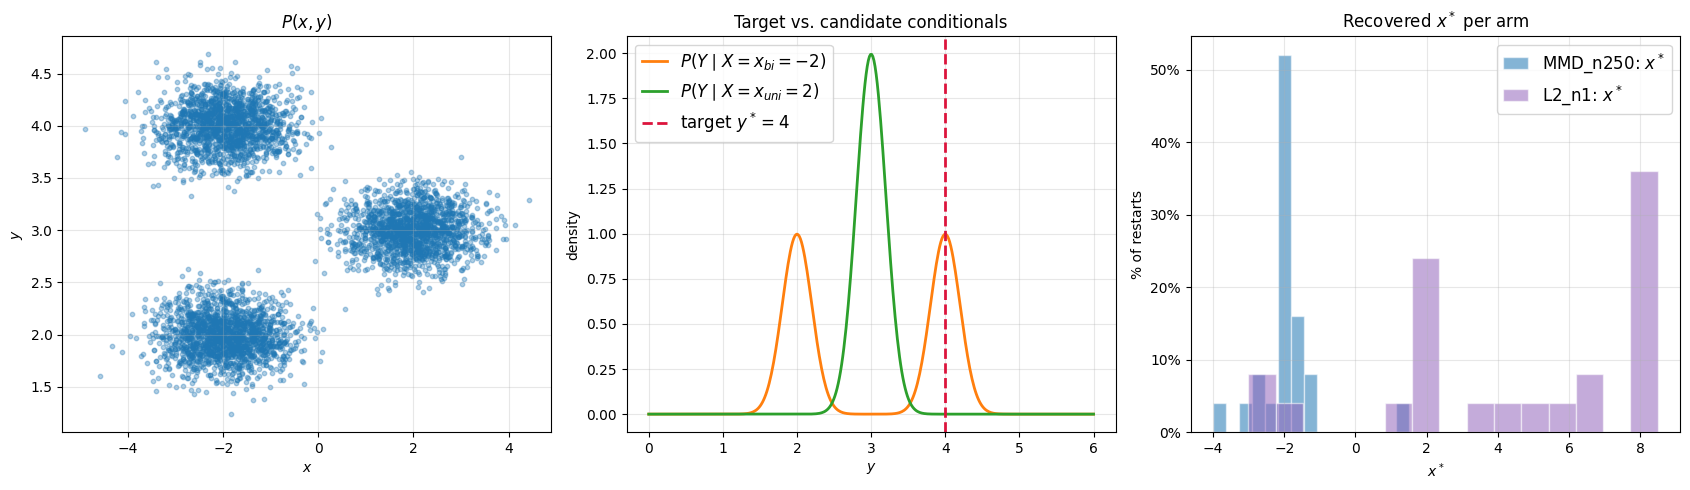

In [79]:
import matplotlib.font_manager as fm

LEGEND_FONTSIZE = 12

fig, (ax_scatter, ax_cond, ax_hist) = plt.subplots(1, 3, figsize=(17, 5))

# --- Left: scatter of the joint P(x,y) ---
xh_cpu = X.detach().cpu().numpy()
ax_scatter.scatter(xh_cpu[:, 0], xh_cpu[:, 1], alpha=0.35, s=10, color="C0")
ax_scatter.set_xlabel(r"$x$")
ax_scatter.set_ylabel(r"$y$")
ax_scatter.set_title(r"$P(x,y)$")
ax_scatter.grid(True, alpha=0.3)

# --- Middle: the two candidate conditionals + the target as a dashed line at y* ---
def gmm_pdf_1d(y_grid, means, variances, weights):
    means_ = means.view(-1)
    vars_  = variances.view(-1)
    w_     = weights.view(-1)
    y = y_grid.view(-1, 1)
    comp_pdf = (1.0 / torch.sqrt(2 * torch.pi * vars_)) * torch.exp(-0.5 * (y - means_) ** 2 / vars_)
    return (comp_pdf * w_).sum(dim=1)

y_grid = torch.linspace(0.0, 6.0, 400)
mu_bi,  S_bi,  w_bi  = true_conditional_at(X_BI)
mu_uni, S_uni, w_uni = true_conditional_at(X_UNI)
pdf_bi  = gmm_pdf_1d(y_grid, mu_bi,  S_bi,  w_bi)
pdf_uni = gmm_pdf_1d(y_grid, mu_uni, S_uni, w_uni)

ax_cond.plot(y_grid.numpy(), pdf_bi.numpy(),  color="C1", lw=2,
             label=rf"$P(Y \mid X{{=}}x_{{bi}}={X_BI:g})$")
ax_cond.plot(y_grid.numpy(), pdf_uni.numpy(), color="C2", lw=2,
             label=rf"$P(Y \mid X{{=}}x_{{uni}}={X_UNI:g})$")
ax_cond.axvline(Y_STAR, color="crimson", ls="--", lw=2, label=rf"target $y^*={Y_STAR:g}$")
ax_cond.set_xlabel(r"$y$")
ax_cond.set_ylabel("density")
ax_cond.set_title("Target vs. candidate conditionals")
ax_cond.legend(loc="upper left")
ax_cond.grid(True, alpha=0.3)

# --- Right: histogram of the recovered x* -- MMD_n250 vs L2_n1 only (L2_n32 excluded) ---
ARM_COLORS = {"MMD_n250": "C0", "L2_n1": "C4"}
PLOT_ARMS = ["MMD_n250", "L2_n1"]
for name in PLOT_ARMS:
    x_preds = np.array([x.item() for x in all_results[name]["x_pred"]])
    weights_pct = np.full_like(x_preds, 100.0 / len(x_preds))
    ax_hist.hist(x_preds, bins=15, weights=weights_pct, alpha=0.55, color=ARM_COLORS.get(name),
                 label=rf"{name}: $x^*$", edgecolor="white")
ax_hist.set_xlabel(r"$x^*$")
ax_hist.set_ylabel("% of restarts")
ax_hist.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter())
ax_hist.set_title(r"Recovered $x^*$ per arm")
ax_hist.legend()
ax_hist.grid(True, alpha=0.3)

plt.tight_layout()

# --- legend styling ---
plt.rcParams['legend.fontsize'] = LEGEND_FONTSIZE
plt.rcParams['legend.handlelength'] = 1.5
for ax in fig.axes:
    leg = ax.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontfamily('sans-serif')

plt.show()

## Save results

In [80]:
def to_python(val):
    if isinstance(val, torch.Tensor):
        return val.detach().cpu().tolist()
    if isinstance(val, np.ndarray):
        return val.tolist()
    if hasattr(val, "item"):
        return val.item()
    return val

out = {
    "experiment": EXPERIMENT_NAME,
    "seed": GLOBAL_SEED,
    "environment": env_info,
    "quick_run": QUICK_RUN,
    "scenario": {
        "x_bi": X_BI, "x_uni": X_UNI, "sigma_x": SIGMA_X, "sigma_y": SIGMA_Y,
        "y_star": Y_STAR, "zero_sigma_eps": ZERO_SIGMA_EPS,
    },
    "meta": {
        "arms": [{"name": name, "loss": loss_name, "nsamples": nsamples} for name, loss_name, nsamples in ARMS],
        "n_attemp_optim": N_ATTEMP_OPTIM,
        "num_x_t_lgd_cm": NUM_X_T_LGD_CM,
        "nepochs": NEPOCHS,
        "x_oracle": X_ORACLE,
        "L_star": L_STAR,
    },
    "arms": {},
}

for name, loss_name, nsamples in ARMS:
    res = all_results[name]
    out["arms"][name] = {
        "loss": loss_name,
        "nsamples": nsamples,
        "x_pred": [to_python(x) for x in res["x_pred"]],
        "final_loss": [to_python(v) for v in res["final_loss"]],
        "l2_gmm": [to_python(v) for v in res["l2_gmm"]],
        "regret": [to_python(v) for v in res["regret"]],
        "times": res["times"],
    }

suffix = "_quickrun" if QUICK_RUN else ""
path = os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_mmd_vs_l2_results_seed{GLOBAL_SEED}{suffix}.json")
with open(path, "w") as f:
    json.dump(out, f, indent=2)
print(f"Results saved to {path}")

Results saved to /content/conditional-matching-paper/simulations/results/nonstar/nonstar_mmd_vs_l2_results_seed42.json
